# Calibration pass — summary figures

Renders the figures for `docs/2026-08-19-calibration-pass-findings.md`.

**Kernel: `du`**, which has pandas, seaborn and matplotlib. Not `docparse` — that
environment is deliberately five pure-Python packages and the pipeline depends on
it staying that way.

Everything is derived from the `scores_*.json` reports. Predictions are gitignored
and machine-specific, so an analysis that read them would run only on the machine
that produced them.

Each figure is written as **SVG** for the web and slides, and **PNG** because
pandoc does not embed SVG into `.docx` — it wants EMF, and quietly drops or
rasterises SVG instead.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

REPO = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(REPO))

# The repo is not installed as a package, so the path insert above must
# precede this import.
from analysis import figures  # noqa: E402

figures.apply_style()
FIGURES = REPO / "docs" / "figures"
print(REPO)

/Users/tod/Desktop/doc-parsing-corpus


## Load

Pass the reports oldest first; a later one wins on a system-name collision, which
is how the superseded prompted runs are replaced by the current ones.

`load` refuses reports that scored different corpora. That is fatal rather than a
warning because a figure mixing two vintages looks entirely normal.

In [2]:
REPORTS = [
    REPO / "scores_parsers.json",  # MinerU — reads no prompt
    REPO / "scores_v4.json",  # gemma 12B 4-bit, InternVL — current prompt
    REPO / "scores_control.json",  # the BF16 precision controls
    REPO / "scores_31b_tp2.json",  # the 31B, on the 2xL4 production will run
]
available = [p for p in REPORTS if p.exists()]
missing = [p.name for p in REPORTS if not p.exists()]
if missing:
    print(f"not yet scored, skipping: {', '.join(missing)}")

# The 31B is quoted from the 2xL4 tp=2 run, because production has no L40S. The
# single-card run (scores_31b.json) is the control, checked two cells down: it
# says sharding changes nothing the deployment rests on.
#
# scores_parsers.json also holds Docling, dropped from the study; figures.EXCLUDED
# removes it here rather than in each chart, so a new figure cannot restore it by
# forgetting to filter.
documents = figures.load(*available)
print(f"{len(documents)} document rows across {documents.system.nunique()} systems")
print(f"excluded: {', '.join(sorted(figures.EXCLUDED))}")
documents.groupby("system").size().sort_index()

990 document rows across 6 systems
excluded: Docling


system
InternVL3.5-8B        165
MinerU                165
gemma 12B 4-bit       165
gemma 12B BF16        165
gemma 12B BF16 QAT    165
gemma 31B 4-bit       165
dtype: int64

## Does the deployment change the answer?

Production has no L40S, so every 31B figure is the 2×L4 `tp=2` run. The
single-card run is kept only to establish that the choice is free — worth
checking rather than assuming, since two other version differences in this study
*did* move results (an OpenCV bump altered 2 of 9 degraded images; MinerU
differs on 41 of 165 pages between Apple Silicon and CUDA).

In [3]:
import json


def statements(report, system):
    rows = json.loads((REPO / report).read_text())["systems"][system]["documents"]
    return [d for d in rows if d["stem"].endswith("_bank_statements")]


deployments = []
for report, system, label in (
    ("scores_31b.json", "gemma-4-31B-it-qat-w4a16-ct", "tp=1  (L40S, 48 GB)"),
    ("scores_31b_tp2.json", "gemma-4-31B-it-qat-w4a16-ct-2xL4-tp2", "tp=2  (2xL4, PROD)"),
):
    if not (REPO / report).exists():
        continue
    d = statements(report, system)
    amounts = sum(x["amounts"] for x in d)
    deployments.append(
        {
            "deployment": label,
            "placed": sum(x["usable"] for x in d) / amounts,
            "attributable": sum(x["attributable"] for x in d) / amounts,
            "misfiled": sum(x["misfiled"] for x in d),
            "rows aligned": sum(x["aligned"] for x in d) / sum(x["truth_rows"] for x in d),
        }
    )
pd.DataFrame(deployments).set_index("deployment").style.format(
    {"placed": "{:.4f}", "attributable": "{:.4f}", "rows aligned": "{:.4f}", "misfiled": "{:.0f}"}
)

,placed,attributable,misfiled,rows aligned
deployment,,,,
"tp=1 (L40S, 48 GB)",0.9901,0.9771,20,0.9473
"tp=2 (2xL4, PROD)",0.9901,0.9771,20,0.9659


## The numbers behind the figures

Medians, not means: a handful of catastrophic pages distort the averages badly,
and quoting means alone misdescribes every system here.

**Ranked by `attributable`, matching the deployment case.** An amount counts
when it has the right value, sits under the right heading, and is in a row
carrying the date that identifies it — which is what a consumer reading rows as
records receives.

Three measures of the same table, increasingly strict, and they do not agree:

| | counts | fails when |
|---|---|---|
| `placed` | amounts under the right heading, any row | the amount moves column |
| `attributable` | ...and in a row carrying its date | the row cannot be identified |
| `rows aligned` | whole rows matching exactly | *anything* in the row is wrong |

**The last two invert two systems**, so which one leads is a real choice rather
than a presentational one. MinerU is 4th on rows aligned and last on
attributable; the 12B 4-bit is last on rows aligned and 4th on attributable.
They fail differently: MinerU reads digits almost perfectly and orphans them in
rows with no date, so its rows often match while its amounts are unusable; the
12B 4-bit keeps its rows intact and misreads digits inside them.

**Why attributable and not rows aligned.** Rows aligned is the strictest and the
least forgiving of trivia: case-sensitive and all-or-nothing, so `SOUTH Yarra`
against `South Yarra AU` fails a row a human would accept. That is the right
severity only if downstream matches on description text. Attributable asks the
question a consumer of amounts actually asks. Both stay in the table, so a
reader whose pipeline matches on text can rank by the other column.

In [4]:
# Deployable systems only. The BF16 12B checkpoints need 48 GB and fit no card
# production has, so they do not belong in a table that reads as a shortlist --
# but they stay in `documents`, because finding 8 rests on them as the precision
# control and dropping them at load would delete that evidence.
DEPLOYABLE = [s for s in documents.system.unique() if "BF16" not in s]
deployable = documents[documents.system.isin(DEPLOYABLE)]

summary = (
    deployable.groupby("system")
    .apply(
        lambda g: pd.Series(
            {
                "median nCER": g.normalised_cer.median(),
                "median sCER": g.strict_cer.median(),
                "gap": (g.strict_cer - g.normalised_cer).median(),
                # Dimension 1: is the value on the page present anywhere?
                "digit recall": g.read.sum() / g.amounts.sum(),
                # Dimension 2, conditional: of what was read, how much is under
                # the right heading.
                "placement": g.placed.sum() / g.read.sum(),
                # Right value, right column, ANY row — the placement figure.
                "placed": g.usable.sum() / g.amounts.sum(),
                # Right value, right column, and in a row carrying the date that
                # identifies it. This is what a consumer reading rows as records
                # receives, and it is the one to quote.
                "attributable": g.attributable.sum() / g.amounts.sum(),
                "rows aligned": g.aligned.sum() / g.truth_rows.sum(),
                "width ok": g.columns_match.sum() / len(g),
            }
        ),
        include_groups=False,
    )
    .sort_values("attributable", ascending=False)
)
summary.style.format("{:.4f}")

,median nCER,median sCER,gap,digit recall,placement,placed,attributable,rows aligned,width ok
system,,,,,,,,,
gemma 31B 4-bit,0.0000,0.0173,0.0149,0.9964,0.9956,0.9920,0.9588,0.9721,0.9818
gemma 12B 4-bit,0.0081,0.0382,0.0136,0.9129,0.9895,0.9033,0.8562,0.6778,0.9879
InternVL3.5-8B,0.0420,0.2119,0.1630,0.9449,0.9188,0.8682,0.7499,0.6698,0.9212
MinerU,0.0403,0.4277,0.3917,0.9093,0.9332,0.8486,0.6105,0.6239,0.6606


In [5]:
# Bank statements alone — the only genuinely hard tables in the corpus. Invoices
# are near-saturated and receipts are a two-column list, so an average over the
# three describes none of them.
#
# `cost` is placed minus attributable: the share of amounts a system files under
# the right heading and then orphans in a row that identifies nothing. It is a
# row-segmentation measure arrived at from the other direction, and it ranks the
# systems the same way fragments do.
statements = deployable[deployable.doc_type == "bank_statements"]
statements.groupby("system").apply(
    lambda g: pd.Series(
        {
            "amounts": g.amounts.sum(),
            "read": g.read.sum() / g.amounts.sum(),
            "placed": g.usable.sum() / g.amounts.sum(),
            "attributable": g.attributable.sum() / g.amounts.sum(),
            "cost": (g.usable.sum() - g.attributable.sum()) / g.amounts.sum(),
            "rows aligned": g.aligned.sum() / g.truth_rows.sum(),
            "fragments": g.fragments.sum(),
        }
    ),
    include_groups=False,
).sort_values("attributable", ascending=False).style.format(
    {"amounts": "{:.0f}", "fragments": "{:.0f}"}, precision=4
)

,amounts,read,placed,attributable,cost,rows aligned,fragments
system,,,,,,,
gemma 31B 4-bit,2011,0.9955,0.9901,0.9771,0.0129,0.9659,0
gemma 12B 4-bit,2011,0.8951,0.8831,0.8528,0.0303,0.6024,0
InternVL3.5-8B,2011,0.9483,0.8528,0.7300,0.1228,0.6123,0
MinerU,2011,0.9786,0.9030,0.6067,0.2964,0.6464,276


## What each configuration delivered

Read from the runs' own `_timing.json` sidecars, on the 2×L4 production has.
Each system is timed the way its weights allow it to be served: weights that fit
a card get `dp=2`, two independent replicas; weights that do not get `tp=2`, one
engine sharded across both.

**A rate flagged `floor` includes model load.** MinerU is invoked as a
subprocess per chunk and reloads each time, so there is no generate-only
interval to time — unlike the engine-driven runners. Its true rate is higher by
an unmeasured margin, and comparing it unflagged would understate it.

In [6]:
timings = figures.throughput(REPO / "runs_throughput")
if timings:
    usable_rate = (
        documents[documents.doc_type == "bank_statements"]
        .groupby("system")[["usable", "amounts"]]
        .sum()
        .pipe(lambda f: f.usable / f.amounts)
    )
    deployment = (
        pd.DataFrame(
            [
                {
                    "system": name,
                    "deployment": t["deployment"],
                    "images/min": t["images_per_minute"],
                    "per card": t["images_per_minute_per_card"],
                    "floor": t["includes_model_load"],
                    "usable (statements)": usable_rate.get(name),
                }
                for name, t in timings.items()
            ]
        )
        .set_index("system")
        .sort_values("per card", ascending=False)
    )
    display(deployment)
else:
    print("no runs_throughput/*/_timing*.json — nothing timed on this machine")

,deployment,images/min,per card,floor,usable (statements)
system,,,,,
MinerU,dp=2,22.20,11.10,True,0.903033
gemma 12B 4-bit,dp=2,13.79,6.90,False,0.883143
InternVL3.5-8B,dp=2,5.47,2.74,False,0.852810
gemma 31B 4-bit,tp=2,5.33,2.67,False,0.990055


## What degraded intake costs

Two ladders over the same 55 statements — a scanner and a phone camera, three
severities each — now for **all four systems**, where earlier passes had only the
31B and MinerU. Degradation never changes the transcript, so one ground truth
serves every tier and any difference is attributable to image quality alone.

`usable` below is **attributable**: right value, right column, and in a row
carrying its identifying date. That is what the case document ranks by and what
the comparison sheets print.

**The 31B leads at every tier, and the margin widens as conditions worsen** —
17.7 points ahead of the next system on scan-light, 33.7 ahead on photo-heavy.
It is not merely better; it is differentially better where production is worst.

**Its failure mode is structural, not perceptual.** On photo-heavy it still
reads 96.4% of amounts correctly while placing only 44.6% usefully. The 12B
fails the opposite way — reading collapses to 39.4%, and 69.8% of what it does
read lands under the wrong heading.

**Photo is the harder channel by a wide margin.** `photo-moderate` is worse than
`scan-heavy` for every system. If production accepts phone photographs, that is
the column to plan against.

**25 pages are declared unproducible and scored as total failures** — token-cap
repetition loops, each evidenced by a file under `_truncated/`. They fall
entirely on the 12B (16) and InternVL (9); the 31B and MinerU produced all 330.
That depresses those two columns, and the ranking does not depend on it:
excluding them lifts the 12B's photo-heavy figure only to roughly 12%.

`docling` is absent because it was never run on a degraded tier. `collect()`
drops a system with a clean point and no ladder rather than drawing a stub,
which would read as a system that held up perfectly.

In [7]:
from analysis.degradation import collect, paired_change, report
from analysis.figures import SHORT

try:
    ladder = collect()
    clean_only = ladder.attrs.get("clean_only")
    if clean_only:
        print(f"clean-only, no ladder, dropped: {', '.join(clean_only)}\n")

    usable = ladder.pivot_table(
        index=["family", "severity"], columns="system", values="usable", observed=True
    )
    usable.columns = [SHORT.get(c, c) for c in usable.columns]
    display((usable * 100).round(1))

    print(report(ladder))
    display(paired_change().set_index(["system", "family", "severity"])[["worse", "better", "same", "net"]])
except SystemExit as err:
    print(err)

clean-only, no ladder, dropped: docling



InternVL3.5-8B  gemma 12B 4-bit  gemma 31B 4-bit  MinerU
family severity                                                          
photo  clean               73.0             85.3             97.7    60.7
       light               69.4             61.8             91.1    56.6
       moderate            42.5             39.5             69.8    45.4
       heavy               18.0             10.9             44.6    31.4
scan   clean               73.0             85.3             97.7    60.7
       light               70.4             80.9             98.6    61.4
       moderate            72.5             88.1             96.7    47.3
       heavy               59.5             67.1             88.6    42.8

Usable bank-statement amounts by image quality

  InternVL3.5-8B  |  photo
    clean     usable 0.7300  (+0.0 pts)   misfiled  296   rows 0.612   digits 0.9689   nCER 0.0749
    light     usable 0.6937  (-3.6 pts)   misfiled  185   rows 0.437   digits 0.9797   nCER 0.1260
    moderate  usable 0.4252  (-30.5 pts)   misfiled  425   rows 0.226   digits 0.9186   nCER 0.1757
    heavy     usable 0.1800  (-55.0 pts)   misfiled  724   rows 0.063   digits 0.7399   nCER 0.2954

  InternVL3.5-8B  |  scan
    clean     usable 0.7300  (+0.0 pts)   misfiled  296   rows 0.612   digits 0.9689   nCER 0.0749
    light     usable 0.7036  (-2.6 pts)   misfiled  259   rows 0.648   digits 0.9637   nCER 0.0959
    moderate  usable 0.7245  (-0.5 pts)   misfiled  137   rows 0.605   digits 0.9904   nCER 0.1059
    heavy     usable 0.5952  (-13.5 pts)   misfiled  235   rows 0.424   digits 0.9541   nCER 0.1357

  gemma-4-12B-it-qat-w4a16-ct  |  photo
    clean     usable 0.8528  (+0.0 pts)   misfiled  235   rows

,,,worse,better,same,net
system,family,severity,,,,
InternVL3.5-8B,photo,light,20,21,14,-111
gemma-4-12B-it-qat-w4a16-ct,photo,light,35,11,9,332
gemma-4-31B-it-qat-w4a16-ct-2xL4-tp2,photo,light,10,9,36,4
mineru-vllm,photo,light,4,2,49,-2
InternVL3.5-8B,photo,moderate,33,13,9,129
gemma-4-12B-it-qat-w4a16-ct,photo,moderate,47,2,6,689
gemma-4-31B-it-qat-w4a16-ct-2xL4-tp2,photo,moderate,19,7,29,33
mineru-vllm,photo,moderate,22,4,29,202
InternVL3.5-8B,photo,heavy,41,10,4,428


## Figures

Each returns the paths it wrote.

In [8]:
written = figures.all_figures(documents, FIGURES, REPO / "runs_throughput")
for path in written:
    print(path.relative_to(REPO), f"{path.stat().st_size // 1024} KB")

docs/figures/01-convention-cost.svg 55 KB
docs/figures/01-convention-cost.png 88 KB
docs/figures/02-numeric-fidelity.svg 54 KB
docs/figures/02-numeric-fidelity.png 91 KB
docs/figures/03-structure-tradeoff.svg 53 KB
docs/figures/03-structure-tradeoff.png 99 KB
docs/figures/04-by-document-type.svg 51 KB
docs/figures/04-by-document-type.png 81 KB
docs/figures/05-pareto-cost-of-accuracy.svg 67 KB
docs/figures/05-pareto-cost-of-accuracy.png 133 KB


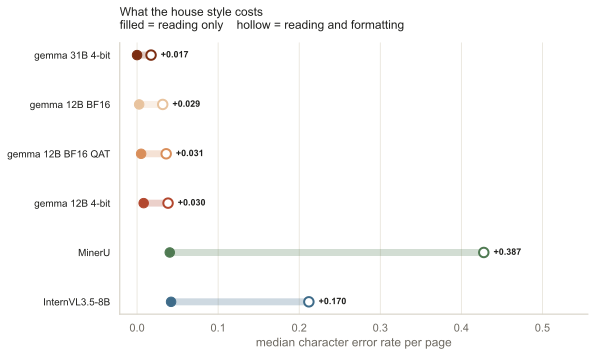

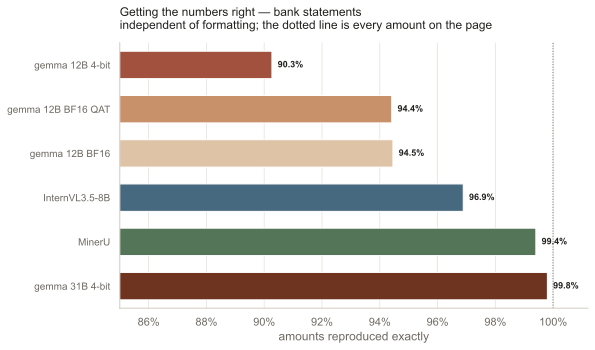

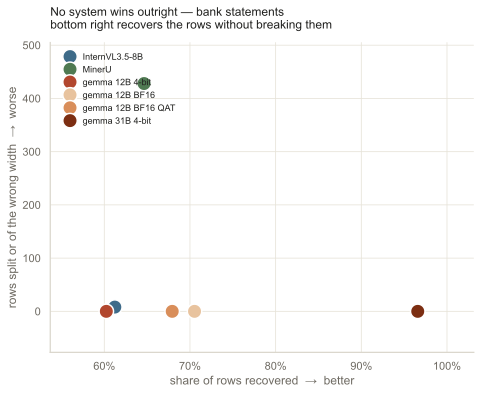

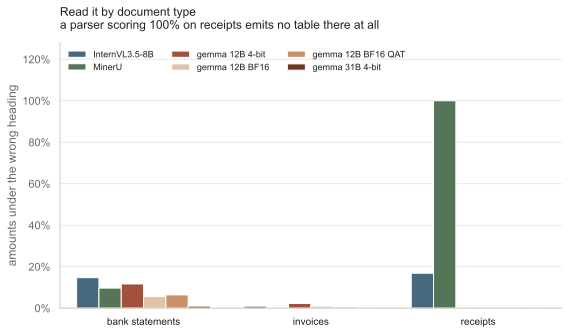

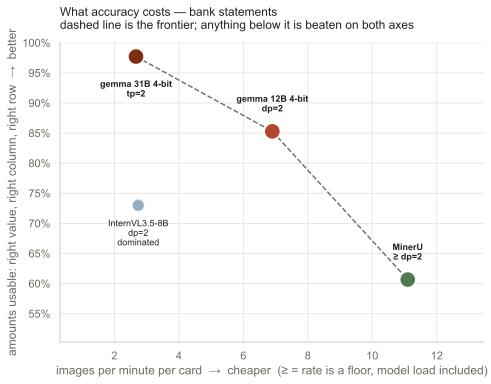

In [9]:
from IPython.display import SVG, display

# The numbered analysis figures. The prompt figures are shown separately below,
# because they document an input rather than report a result.
for path in sorted(FIGURES.glob("[0-9]*.svg")):
    display(SVG(filename=str(path)))

## The prompt

Findings 1, 2, 3 and 6 all turn on the exact wording of `config/prompt.md`, so it
is reproduced here one convention per figure. This is the text sent to every
prompted system — 974 words of the file's 1,018, since the preamble above the
`---` rule addresses whoever runs the benchmark and never reaches the model.

**These figures are ASCII by construction.** Pygments substitutes U+00A0 for
every space so that runs of them survive in SVG, and GitHub's notebook viewer
renders non-ASCII inside a `<text>` element as escaped UTF-8 bytes — a prompt
reading `Transcribe\xc2\xa0this\xc2\xa0document` rather than words. Spacing is
held by `xml:space="preserve"` instead, so nothing is lost. The cell below
re-checks it rather than trusting it.

12 convention figure(s), 1 whole-prompt figure
non-ASCII: none


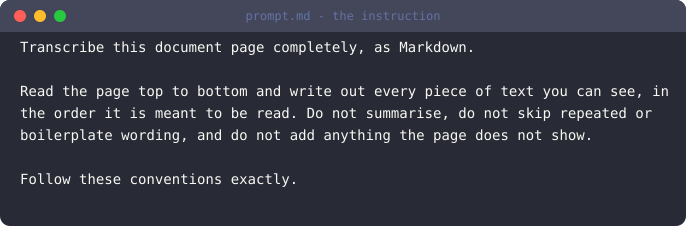

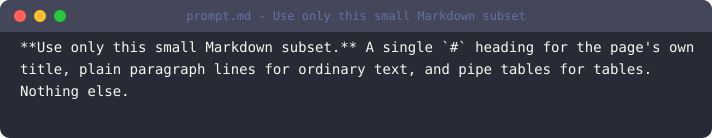

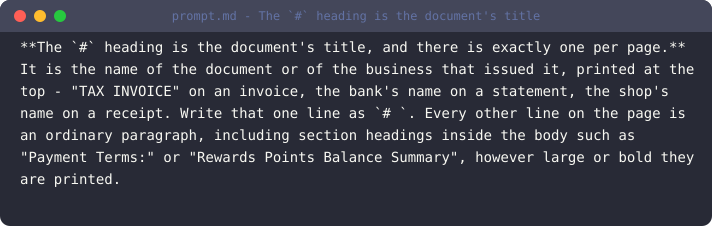

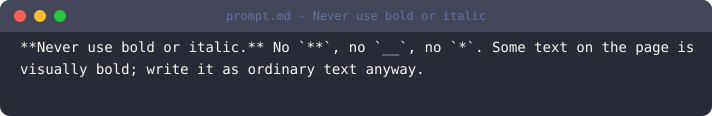

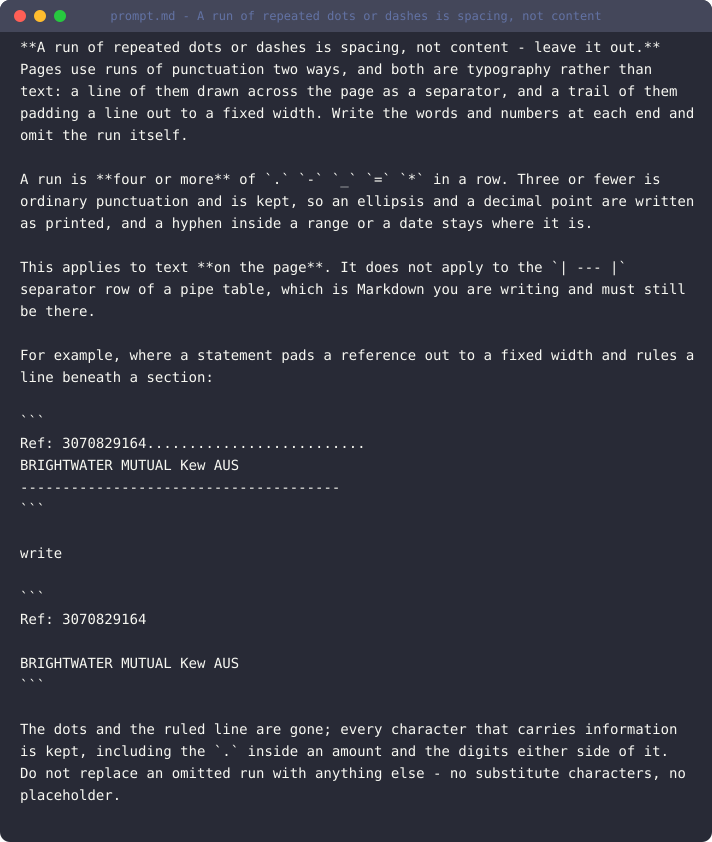

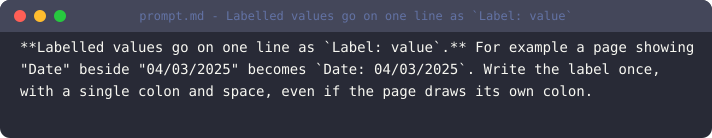

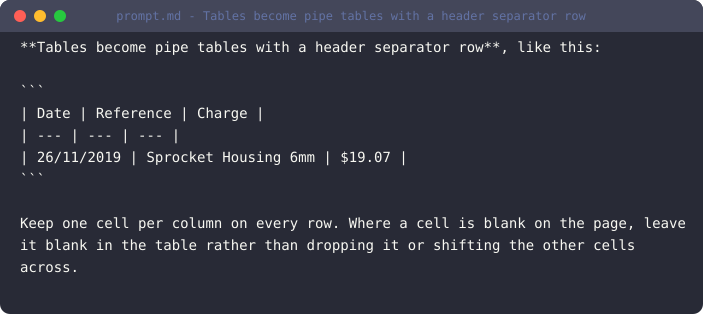

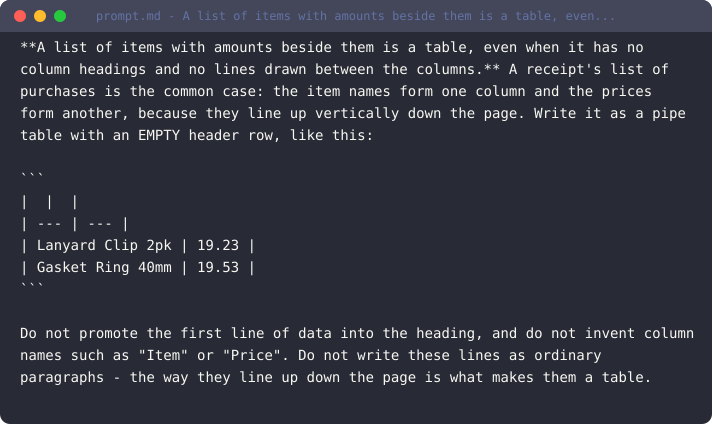

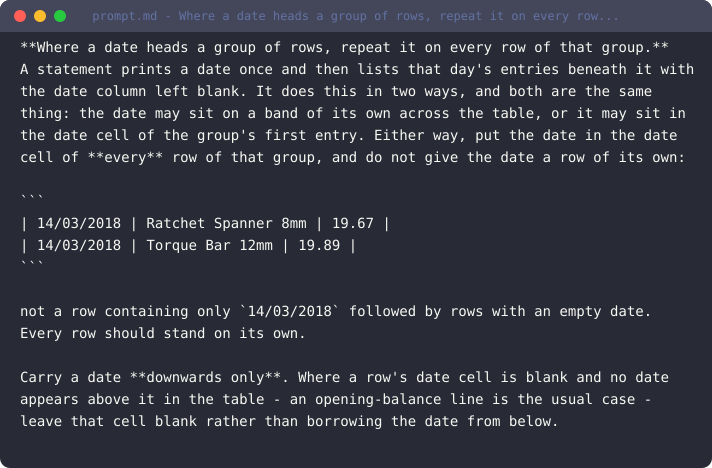

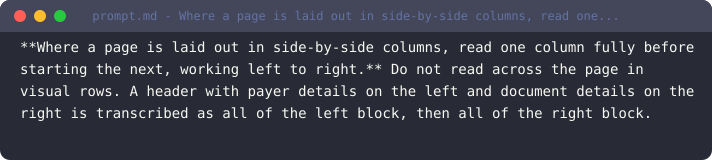

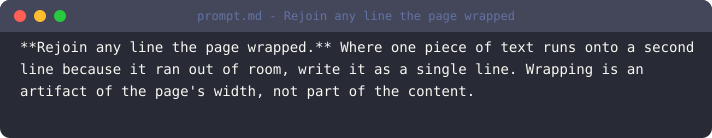

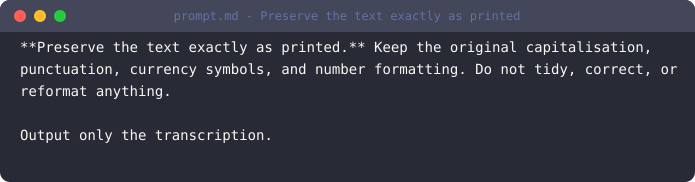

In [10]:
prompts = sorted(FIGURES.glob("prompt-*.svg"))
whole = [p for p in prompts if p.stem.startswith("prompt-00")]
sections = [p for p in prompts if not p.stem.startswith("prompt-00")]

# A check rather than a claim: anything above U+007F here renders as escaped
# bytes in the viewer this notebook is read in.
offenders = [p.name for p in prompts if any(ord(c) > 126 for c in p.read_text(encoding="utf-8"))]
print(f"{len(sections)} convention figure(s), {len(whole)} whole-prompt figure")
print(f"non-ASCII: {offenders or 'none'}")

for path in sections:
    display(SVG(filename=str(path)))

## Download

Click to save. SVG for the web and slides; PNG for the `.docx` path.

In [11]:
from IPython.display import FileLinks

FileLinks(str(FIGURES.relative_to(REPO)))

Path ( docs/figures ) doesn't exist. It may still be in the process of being generated, or you may have the incorrect path.